# ARIMA Visualization

## Install libraries

In [1]:
# !pip install -r ../../requirements.txt

## Import libraries

In [2]:
import os
import sys
import pandas as pd
from scipy.stats import boxcox
from statsmodels.graphics.tsaplots import plot_pacf, plot_acf
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from scipy.special import inv_boxcox

# go one level up from where the notebook is running
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

from logger.logger import Logger, LogType
from visualizer.visualizer import Visualizer
from model.arima_model import ArimaModel
from utils.constants import *
from utils.enums import *
from dtos.tabular_database_driver_dtos.tabular_database_driver_dtos import *

## Helper functions

In [3]:
def auto_convert(df: pd.DataFrame) -> pd.DataFrame:
    for col in df.columns:
        # Dates
        if "date" in col.lower():
            df[col] = pd.to_datetime(df[col], errors="coerce")

        # Codes
        elif "code" in col.lower():
            df[col] = df[col].astype("string")

        # Market IDs
        elif "market_id" in col.lower():
            df[col] = pd.to_numeric(df[col], errors="coerce").astype("Int64")

        # OHLC
        elif col.lower() in ["open", "high", "low", "close"]:
            df[col] = pd.to_numeric(df[col], errors="coerce").astype(float)

        # Volume
        elif "volume" in col.lower():
            df[col] = pd.to_numeric(df[col], errors="coerce").astype("Int64")

    return df

## Initialize the Logger

In [4]:
my_logger = Logger(file_name=ARIMA_VISUALIZATION_LOG_FILE_BASE)

## Initialize the Visualizer

In [5]:
my_visualizer = Visualizer(logger=my_logger)

## Initialize the ArimaModel

In [6]:
arima_model = ArimaModel(logger=my_logger)

## Parameters

In [7]:
stock_code = "FPT"
value_column_name = "close"

## Load data

In [8]:
arima_model.connect_to_database(database_name=os.getenv("BRONZE_POSTGRES_DATABASE"))

<DatabaseExecutionStatus.SUCCESS: 'success'>

In [9]:
df = arima_model.select(
    schema_name="enterprise",
    table_name="daily_price",
    conditions=[
        Condition(
            column="code",
            operator=SqlOperator.EQUAL_TO,
            value=stock_code,
            data_type=DataType.VARCHAR,
        )
    ],
    order_by=["date"],
)
df = auto_convert(df)
df

,date,code,market_id,open,high,low,close,volume
0,2006-12-13,FPT,1,9.8400,9.8400,9.8400,9.8613,83530
1,2006-12-14,FPT,1,10.3320,10.3320,10.3320,10.3543,280710
2,2006-12-15,FPT,1,10.8486,10.8486,10.8486,10.8721,265300
3,2006-12-18,FPT,1,11.3898,11.3898,11.3898,11.4144,215790
4,2006-12-19,FPT,1,11.9556,11.9556,11.9556,11.9814,137520
...,...,...,...,...,...,...,...,...
4641,2025-08-06,FPT,1,106.0000,106.2000,104.5000,104.9000,11814200
4642,2025-08-07,FPT,1,105.6000,107.4000,104.9000,106.2000,9565800
4643,2025-08-08,FPT,1,106.5000,107.4000,104.8000,105.6000,9184800
4644,2025-08-11,FPT,1,105.9000,109.5000,105.3000,106.4000,10278500


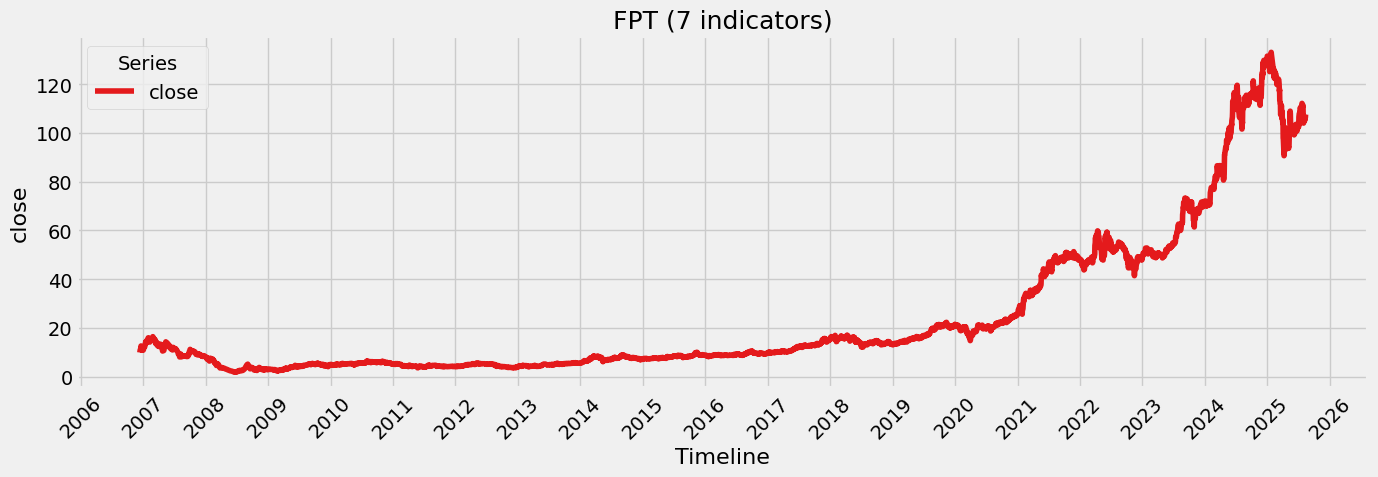

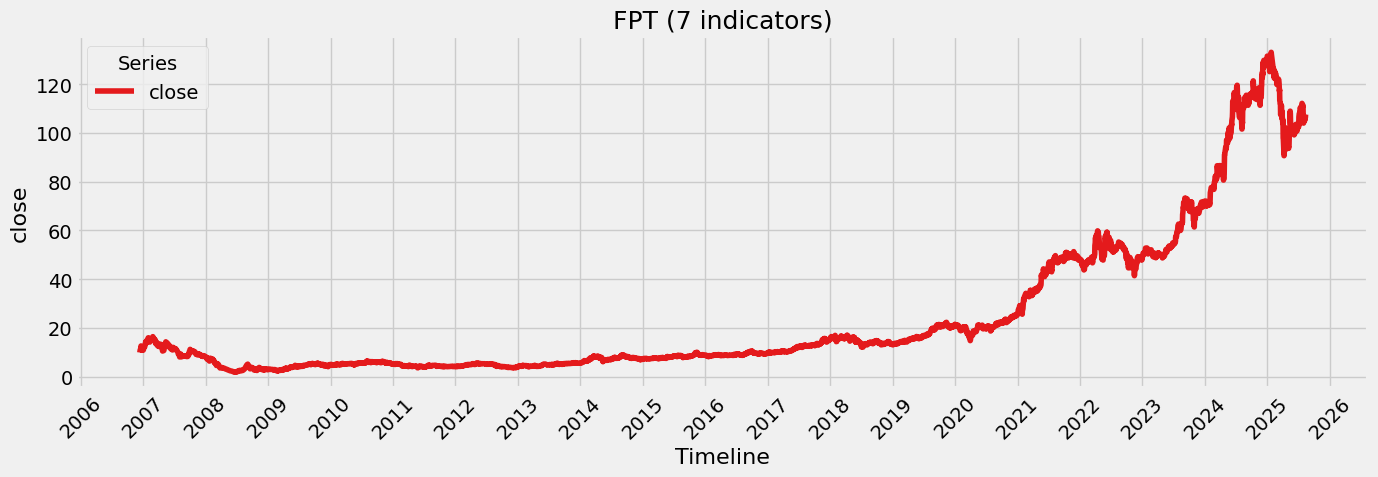

In [10]:
my_visualizer.plot_lines_chart(
    df,
    x_column="date",
    y_columns=[value_column_name],
    title=stock_code,
    y_axis_title=value_column_name,
    y_unit="",
    prefix_figure_name=stock_code,
    marker=None,
)

## Divide data into train and test

In [11]:
train = df.iloc[: -int(len(df) * 0.2)]
test = df.iloc[-int(len(df) * 0.2) :]

In [12]:
train

,date,code,market_id,open,high,low,close,volume
0,2006-12-13,FPT,1,9.8400,9.8400,9.8400,9.8613,83530
1,2006-12-14,FPT,1,10.3320,10.3320,10.3320,10.3543,280710
2,2006-12-15,FPT,1,10.8486,10.8486,10.8486,10.8721,265300
3,2006-12-18,FPT,1,11.3898,11.3898,11.3898,11.4144,215790
4,2006-12-19,FPT,1,11.9556,11.9556,11.9556,11.9814,137520
...,...,...,...,...,...,...,...,...
3712,2021-11-11,FPT,1,49.7416,50.2544,49.1262,49.2288,2122200
3713,2021-11-12,FPT,1,49.3314,50.3570,49.1775,50.2544,2240300
3714,2021-11-15,FPT,1,50.5010,50.5010,49.8857,49.8954,1908900
3715,2021-11-16,FPT,1,49.8857,51.0137,49.6294,50.4082,3506200


In [13]:
test

,date,code,market_id,open,high,low,close,volume
3717,2021-11-18,FPT,1,50.4082,50.6134,49.4852,49.4852,2005000
3718,2021-11-19,FPT,1,49.9883,50.1421,48.7578,48.8698,2481300
3719,2021-11-22,FPT,1,48.9724,49.2288,48.7160,48.7160,1670100
3720,2021-11-23,FPT,1,48.7160,49.5365,48.6647,49.5365,1150800
3721,2021-11-24,FPT,1,49.5781,50.4497,49.4243,50.2031,2445600
...,...,...,...,...,...,...,...,...
4641,2025-08-06,FPT,1,106.0000,106.2000,104.5000,104.9000,11814200
4642,2025-08-07,FPT,1,105.6000,107.4000,104.9000,106.2000,9565800
4643,2025-08-08,FPT,1,106.5000,107.4000,104.8000,105.6000,9184800
4644,2025-08-11,FPT,1,105.9000,109.5000,105.3000,106.4000,10278500


## Fit the model

In [14]:
arima_model.fit(
    series=train[value_column_name],
    max_p=5,
    max_d=1,
    max_q=5,
    criterion="bic",
    model_suffix=None,
)

d:\DATA SCIENCE\GIT\master-thesis\mt_env\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
Searching ARIMA orders (parallelized): 100%|██████████| 71/71 [00:16<00:00,  4.42it/s]
d:\DATA SCIENCE\GIT\master-thesis\src\model\arima_model.py:55: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  stat, p_value, nlags, crit = kpss(


In [15]:
arima_model.get_order()

(1, 1, 0)

## Forecast

In [16]:
forecast = arima_model.forecast(steps=len(test))  # next 12 periods

In [17]:
forecast

3717    50.4082
3718    50.4082
3719    50.4082
3720    50.4082
3721    50.4082
         ...   
4641    50.4082
4642    50.4082
4643    50.4082
4644    50.4082
4645    50.4082
Name: forecast, Length: 929, dtype: float64

Figure saved to: ../../charts/arima\FPT_1_1_0.png


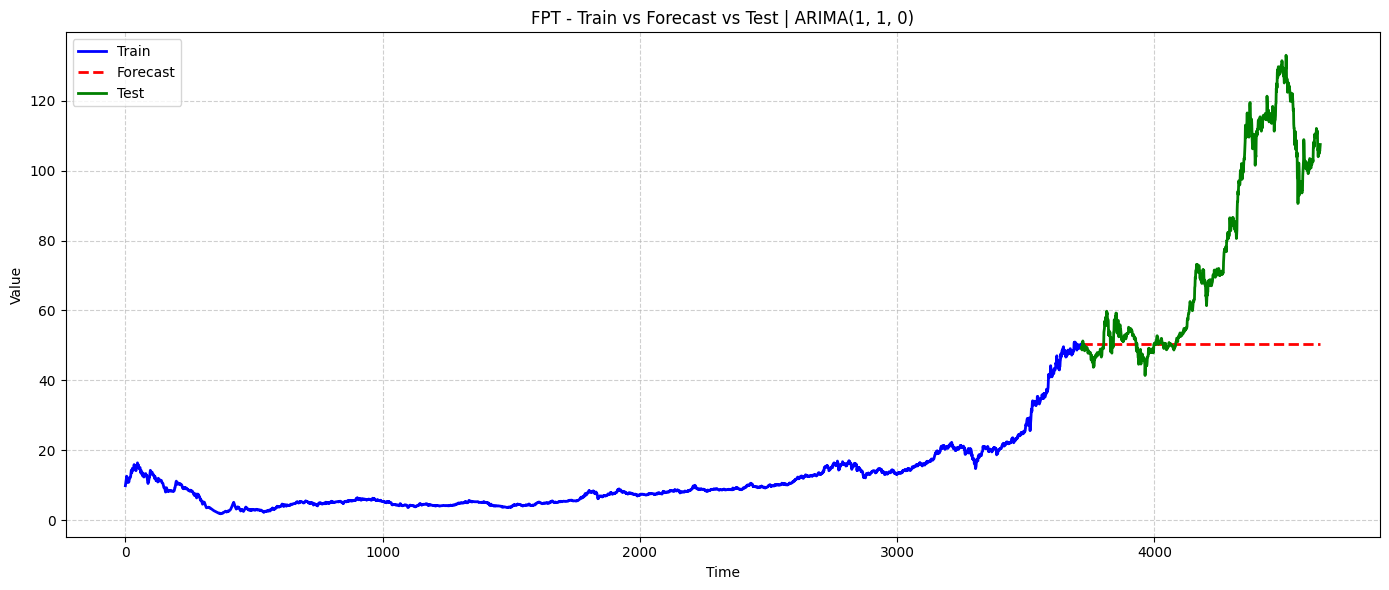

In [18]:
arima_model.plot_forecast(
    steps=len(test),
    test=test[value_column_name],
    title=f"{stock_code} - Train vs Forecast vs Test",
    file_name=stock_code
)